# Life Expectancy and GDP Analysis

## Project Overview
This project explores the relationship between life expectancy at birth and GDP across different countries over time. The analysis focuses on understanding trends in health outcomes, differences between countries, and whether economic growth is associated with longer life expectancy.

## Problem Statement
Life expectancy is often used as an indicator of a country's overall health and quality of life, while GDP reflects economic performance. This project investigates whether higher GDP is linked to higher life expectancy and how both variables change over time across countries.

## Goals
- Explore how life expectancy changes over time for each country
- Compare GDP trends across countries
- Investigate the relationship between GDP and life expectancy
- Identify countries that perform better or worse than expected

## Objectives
- Load and inspect the dataset
- Clean the data and check for missing values
- Summarize the dataset using descriptive statistics
- Visualize life expectancy trends by country
- Visualize GDP trends by country
- Analyze the relationship between GDP and life expectancy
- Draw conclusions based on the results

## Questions
- How has life expectancy changed over time in each country?
- How has GDP changed over time in each country?
- Is there a relationship between GDP and life expectancy?
- Which countries have the highest and lowest life expectancy?
- Are there countries that stand out from the overall trend?

## Hypothesis
Countries with higher GDP tend to have higher life expectancy. In addition, life expectancy is expected to improve over time in most countries.


In [71]:

# Import libraries needed for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
import statsmodels
import matplotlib.pyplot as plt
import math

# Set a clean visual style for plots
sns.set_theme(style="whitegrid", palette="Set2")

In [36]:
# Load the dataset
df = pd.read_csv('all_data.csv')

# Display the first 5 rows
df.head()

,Country,Year,Life expectancy at birth (years),GDP
0,Chile,2000,77.3,7.786093e+10
1,Chile,2001,77.3,7.097992e+10
2,Chile,2002,77.8,6.973681e+10
3,Chile,2003,77.9,7.564346e+10
4,Chile,2004,78.0,9.921039e+10


## Data Inspection
In this section, we examine the structure of the dataset, check the column names, and review the data types. This helps us understand what kind of cleaning or preparation may be needed before analysis.


In [37]:
# Show the shape of the dataset
df.shape

(96, 4)

In [39]:
# Display the column names
df.columns

Index(['Country', 'Year', 'Life expectancy at birth (years)', 'GDP'], dtype='object')

In [40]:
# Check data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Country                           96 non-null     object 
 1   Year                              96 non-null     int64  
 2   Life expectancy at birth (years)  96 non-null     float64
 3   GDP                               96 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 3.1+ KB


In [41]:
# Summary statistics for numerical columns
df.describe(include= 'all')

,Country,Year,Life expectancy at birth (years),GDP
count,96,96.000000,96.000000,9.600000e+01
unique,6,NaN,NaN,NaN
top,Chile,NaN,NaN,NaN
freq,16,NaN,NaN,NaN
mean,NaN,2007.500000,72.789583,3.880499e+12
std,NaN,4.633971,10.672882,5.197561e+12
min,NaN,2000.000000,44.300000,4.415703e+09
25%,NaN,2003.750000,74.475000,1.733018e+11
50%,NaN,2007.500000,76.750000,1.280220e+12
75%,NaN,2011.250000,78.900000,4.067510e+12


## Data Cleaning
Before starting the analysis, we need to check for missing values and make sure the data types are correct.


In [43]:
# Check for missing values in each column
df.isnull().sum()

Country                             0
Year                                0
Life expectancy at birth (years)    0
GDP                                 0
dtype: int64

In [52]:
# Rename columns if needed to make them easier to work with
df = df.rename(columns={
    "Life expectancy at birth (years)": "life_expectancy",
    "GDP": "gdp"
})

In [54]:
df.columns = df.columns.str.lower()

# Display updated column names
df.columns

Index(['country', 'year', 'life_expectancy', 'gdp'], dtype='object')

## Exploratory Data Analysis
This section explores patterns in the dataset and answers the main research questions using tables and graphs.


In [55]:
# Check how many unique countries are in the dataset
df["country"].nunique()


6

In [56]:
# Display the countries included in the dataset
df["country"].unique()


array(['Chile', 'China', 'Germany', 'Mexico', 'United States of America',
       'Zimbabwe'], dtype=object)

In [57]:
# Find the range of years in the dataset
df["year"].min(), df["year"].max()


(2000, 2015)

## Life Expectancy Over Time
This graph shows how life expectancy has changed over time for each country.


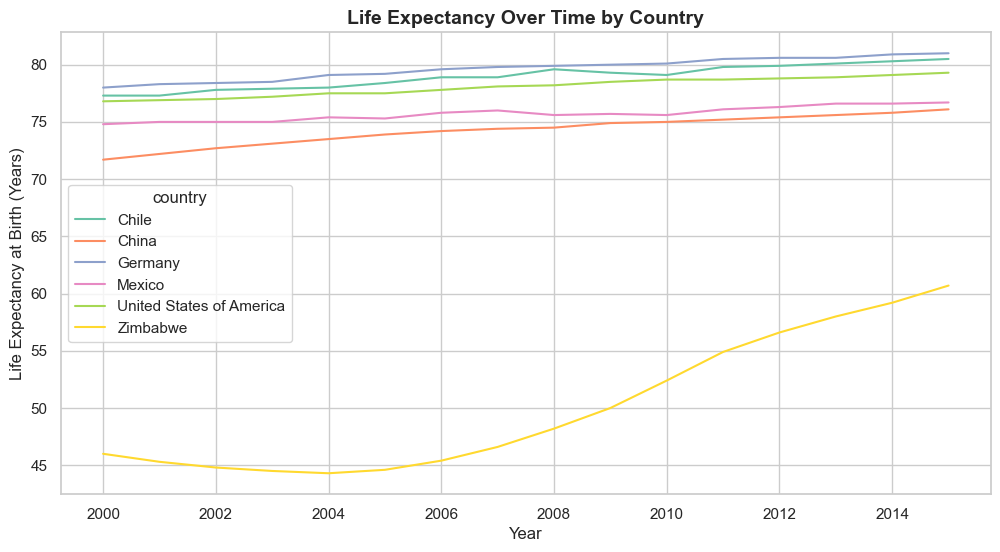

In [59]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="year", y="life_expectancy", hue="country")
plt.title("Life Expectancy Over Time by Country", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Life Expectancy at Birth (Years)", fontsize=12)
plt.show()

### Insight
This chart helps show whether life expectancy is increasing, decreasing, or staying stable in each country over time.


## GDP Over Time
This graph shows how GDP has changed over time for each country.


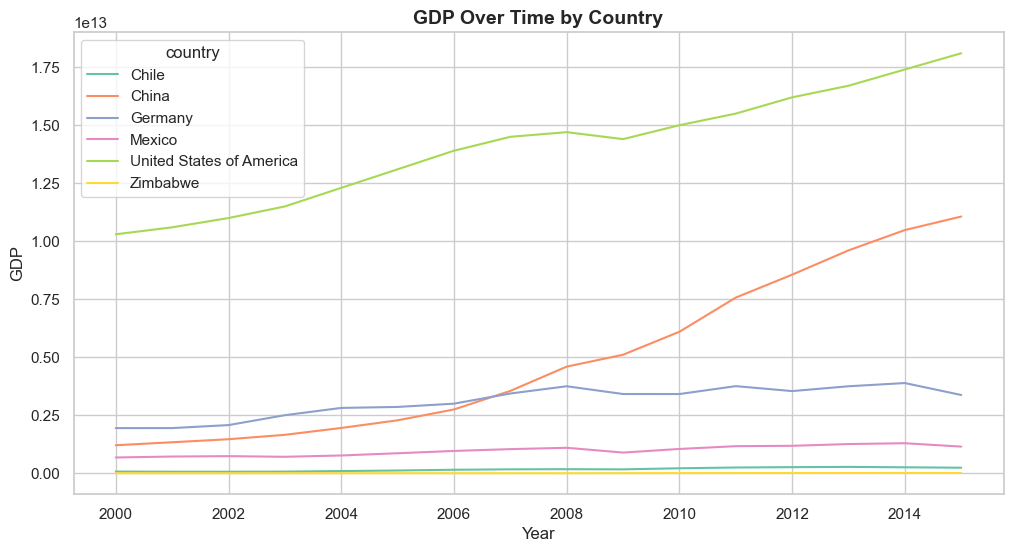

In [60]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x="year", y="gdp", hue="country")
plt.title("GDP Over Time by Country", fontsize=14, fontweight="bold")
plt.xlabel("Year", fontsize=12)
plt.ylabel("GDP", fontsize=12)
plt.show()


### Insight
This chart allows us to compare economic growth patterns across countries and identify which countries experienced stronger GDP growth.


## Relationship Between GDP and Life Expectancy
This scatter plot shows whether countries with higher GDP also tend to have higher life expectancy.


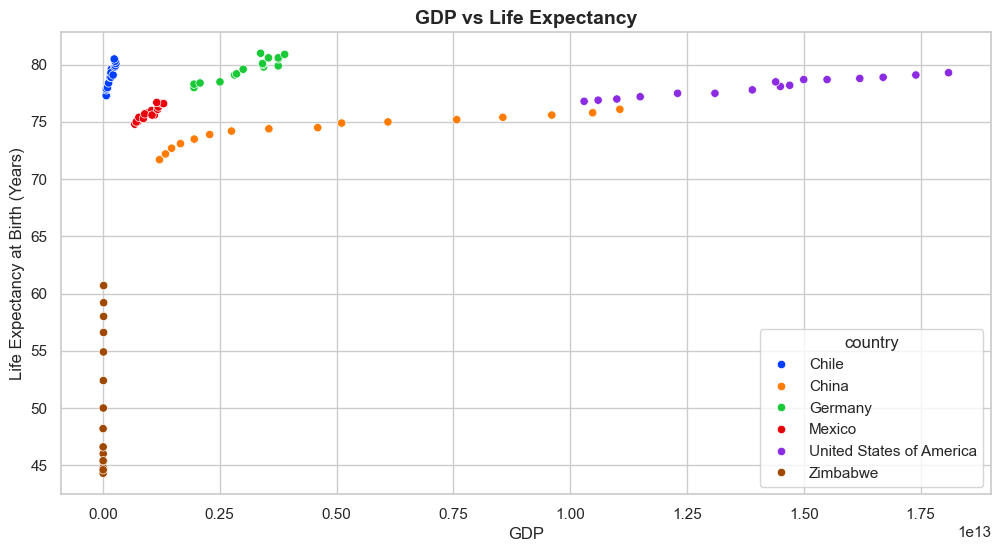

In [62]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x="gdp", y="life_expectancy", hue="country", palette="bright")
plt.title("GDP vs Life Expectancy", fontsize=14, fontweight="bold")
plt.xlabel("GDP", fontsize=12)
plt.ylabel("Life Expectancy at Birth (Years)", fontsize=12)
plt.show()


### Insight
If the points generally move upward as GDP increases, this suggests a positive relationship between GDP and life expectancy.



## Average Life Expectancy by Country
This bar chart compares the average life expectancy of each country.


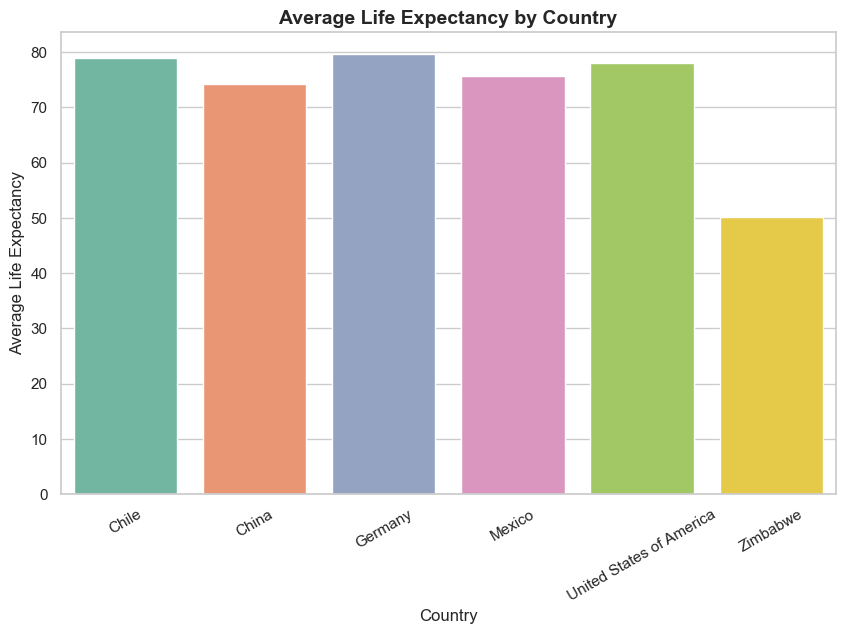

In [64]:
avg_life = df.groupby("country")["life_expectancy"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_life, x="country", y="life_expectancy", hue="country", legend=False, palette="Set2")
plt.title("Average Life Expectancy by Country", fontsize=14, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Average Life Expectancy", fontsize=12)
plt.xticks(rotation=30)
plt.show()


### Insight
This graph helps identify which countries have the highest and lowest average life expectancy.


## Average GDP by Country
This bar chart compares the average GDP of each country.


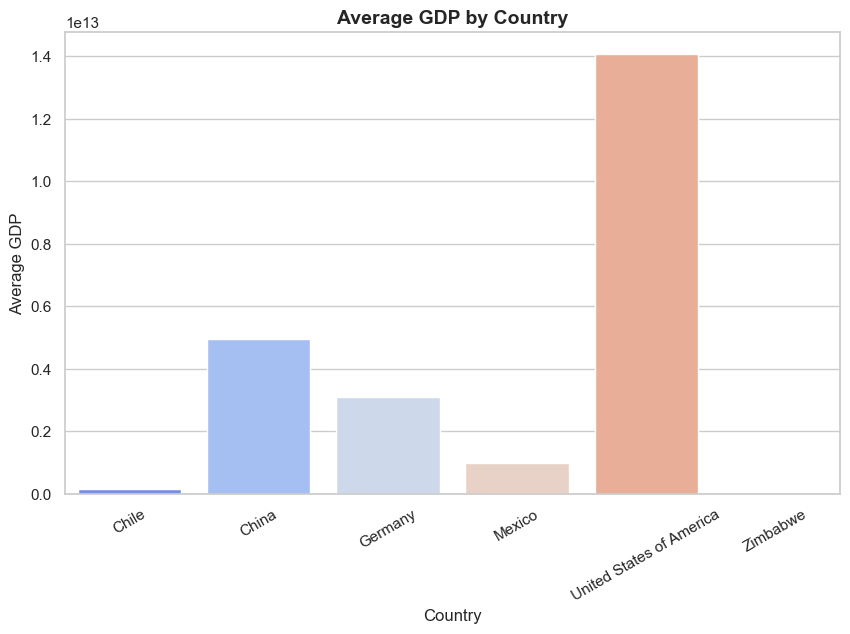

In [65]:
avg_gdp = df.groupby("country")["gdp"].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_gdp, x="country", y="gdp", hue="country", legend=False, palette="coolwarm")
plt.title("Average GDP by Country", fontsize=14, fontweight="bold")
plt.xlabel("Country", fontsize=12)
plt.ylabel("Average GDP", fontsize=12)
plt.xticks(rotation=30)
plt.show()


### Insight
This chart helps compare the economic size of each country on average across the years in the dataset.


## Country with Highest and Lowest Life Expectancy
This section identifies the countries with the highest and lowest observed life expectancy values.


In [66]:
# Row with highest life expectancy
df.loc[df["life_expectancy"].idxmax()]

country                    Germany
year                          2015
life_expectancy               81.0
gdp                3375610000000.0
Name: 47, dtype: object

In [67]:
# Row with lowest life expectancy
df.loc[df["life_expectancy"].idxmin()]


country                Zimbabwe
year                       2004
life_expectancy            44.3
gdp                5805598400.0
Name: 84, dtype: object

## Correlation Between GDP and Life Expectancy
A correlation value helps measure the strength of the relationship between GDP and life expectancy.


In [68]:
# Calculate correlation
df["gdp"].corr(df["life_expectancy"])


np.float64(0.3432067484491559)

## Hypothesis Testing

In this section, we test whether there is a statistically significant relationship between GDP and life expectancy.

### Hypotheses
- Null hypothesis (H0): There is no significant relationship between GDP and life expectancy.
- Alternative hypothesis (H1): There is a significant relationship between GDP and life expectancy.


In [70]:
# Calculate Pearson correlation and p-value
corr, p_value = pearsonr(df["gdp"], df["life_expectancy"])

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.343206748449156
P-value: 0.0006187129569469888


### Interpretation
- The correlation value shows the direction and strength of the relationship
- The p-value shows whether the relationship is statistically significant
- If the p-value is less than 0.05, we reject the null hypothesis


## Linear Regression

Linear regression is used to examine whether GDP can predict life expectancy. In this model:
- GDP is the independent variable
- Life expectancy is the dependent variable


In [72]:
# Reshape GDP because sklearn expects a 2D input
X = df[["gdp"]]
y = df["life_expectancy"]

# Create and fit the model
model = LinearRegression()
model.fit(X, y)

# Predict life expectancy values
y_pred = model.predict(X)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])
print("R-squared:", model.score(X, y))

Intercept: 70.05478412327241
Slope: 7.047545979431694e-13
R-squared: 0.11779087218104212


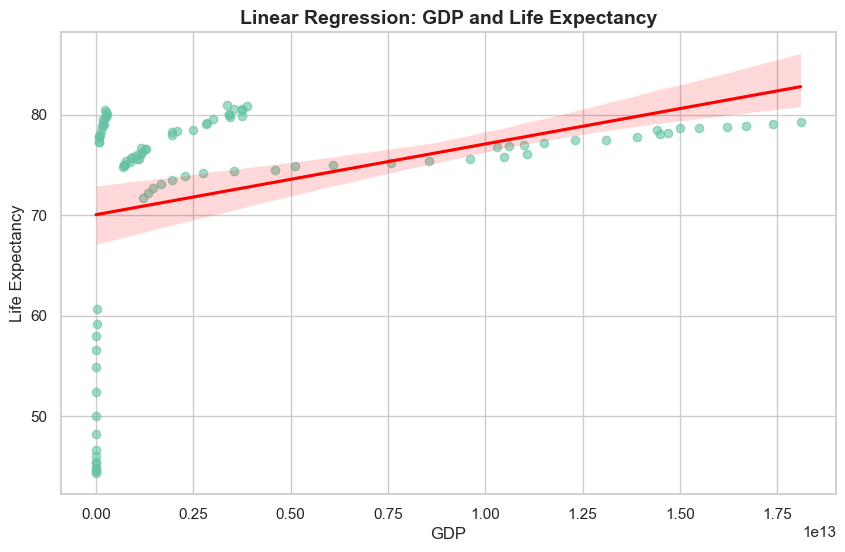

In [73]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x="gdp", y="life_expectancy", scatter_kws={"alpha":0.6}, line_kws={"color":"red"})
plt.title("Linear Regression: GDP and Life Expectancy", fontsize=14, fontweight="bold")
plt.xlabel("GDP", fontsize=12)
plt.ylabel("Life Expectancy", fontsize=12)
plt.show()


### Interpretation
The scatter points show the actual data, while the red line shows the overall trend. If the line slopes upward, it suggests that higher GDP is associated with higher life expectancy.


## Key Findings
Write your main findings here after reviewing the graphs and results.

Example:
- Life expectancy generally increased over time in most countries
- GDP also increased in several countries, but at different rates
- Countries with higher GDP often had higher life expectancy
- Some countries performed better or worse than expected compared to their GDP


## Statistical Insight

The hypothesis test and regression model help determine whether GDP and life expectancy are related in a meaningful way. If the p-value is small and the regression slope is positive, this suggests that countries with higher GDP tend to have higher life expectancy. The R-squared value shows how much of the variation in life expectancy can be explained by GDP alone.


## Conclusion
This project explored trends in life expectancy and GDP across countries over time. The analysis suggests that life expectancy tends to improve over time and that there is often a positive relationship between GDP and life expectancy. However, GDP alone may not explain all differences between countries, which suggests that other social and health factors may also be important.
